# gradient-sankey — a gallery

> **A Python library for beautiful, animated, true-gradient Sankey diagrams.**
> Install it from PyPI:
> ```bash
> pip install gradient-sankey
> ```

This notebook calls the **installed package** and builds a series of Sankey
diagrams — each one styled with the new `Theme` design system — and finishes
with a short **animation**. Every image below is rendered by the library itself.

> **Run me first.** A `pip install` you ran in a terminal may have targeted a
> *different* Python than this notebook's kernel — the usual cause of a
> `ModuleNotFoundError` here. The `%pip` magic below installs into **this
> kernel's** environment, so it works regardless of which interpreter is
> selected.


In [1]:
%pip install -q gradient-sankey

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Felipe\AppData\Local\Temp\gs_pypi\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import gradient_sankey as gs
from gradient_sankey import (
    SankeyRaceMultiLayerParallel as Sankey,
    Theme, NodeStyle, LinkStyle, ColorPalette, get_palette_colors,
)
import pandas as pd
from IPython.display import Image, Video, display

print("gradient-sankey version:", gs.__version__)   # proves which build we're calling

import os
ASSET = "gallery_assets"
os.makedirs(ASSET, exist_ok=True)

def one_period(flows, layers, colors):
    "Build a single-period Sankey from a {(src,tgt): value} dict."
    df = pd.DataFrame([{"t": 0, "s": s, "d": d, "v": v} for (s, d), v in flows.items()])
    return Sankey.from_dataframe(df, layers, time_col="t", source_col="s",
                                 target_col="d", value_col="v", node_colors=colors)

gradient-sankey version: 1.2.0


## 1. The gradient, simply

The signature feature: each link is a smooth cubic-Bézier ribbon whose color
**flows** from the source node's hue to the target's. Here a monthly budget
splits into three buckets — notice how every ribbon is a true gradient, not a
flat band.

Frame saved to: gallery_assets/01_budget.png


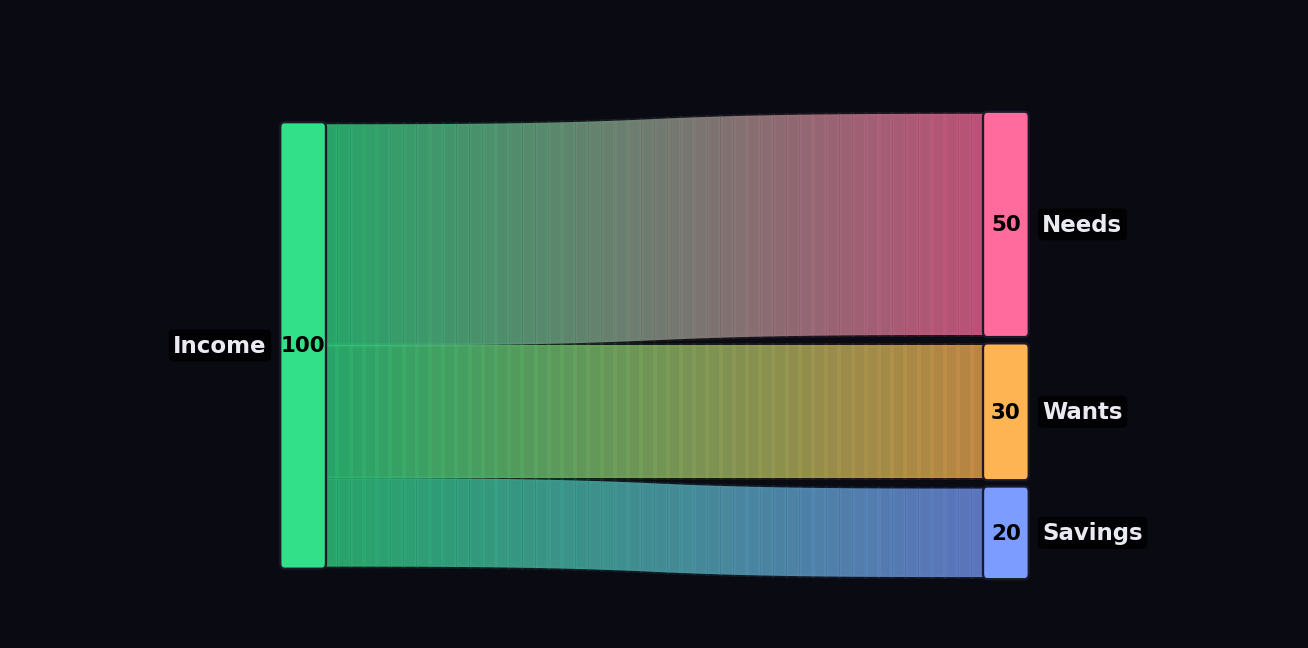

In [3]:
budget = {
    ("Income", "Needs"):   50,
    ("Income", "Wants"):   30,
    ("Income", "Savings"): 20,
}
budget_layers = [["Income"], ["Needs", "Wants", "Savings"]]
budget_colors = {"Income": "#33E08A", "Needs": "#FF6B9D",
                 "Wants": "#FFB454", "Savings": "#7C9CFF"}

sk = one_period(budget, budget_layers, budget_colors)
sk.save_frame(f"{ASSET}/01_budget.png", figsize=(12, 6), dpi=110, font_size=15,
              theme=Theme.dark(), link_glow=1, link_alpha=0.7,
              stacked_mode=True, ranking_mode=False, padding=1.6)
Image(f"{ASSET}/01_budget.png")

## 2. Any flow — an energy system

The engine doesn't care what the numbers *mean*. Point it at an energy system —
**sources → carriers → end use** — and the gradients keep a dense, many-to-many
flow readable. Colors come from the library's built-in palettes
(`ColorPalette.EARTH / OCEAN / NEON`).

Frame saved to: gallery_assets/02_energy.png


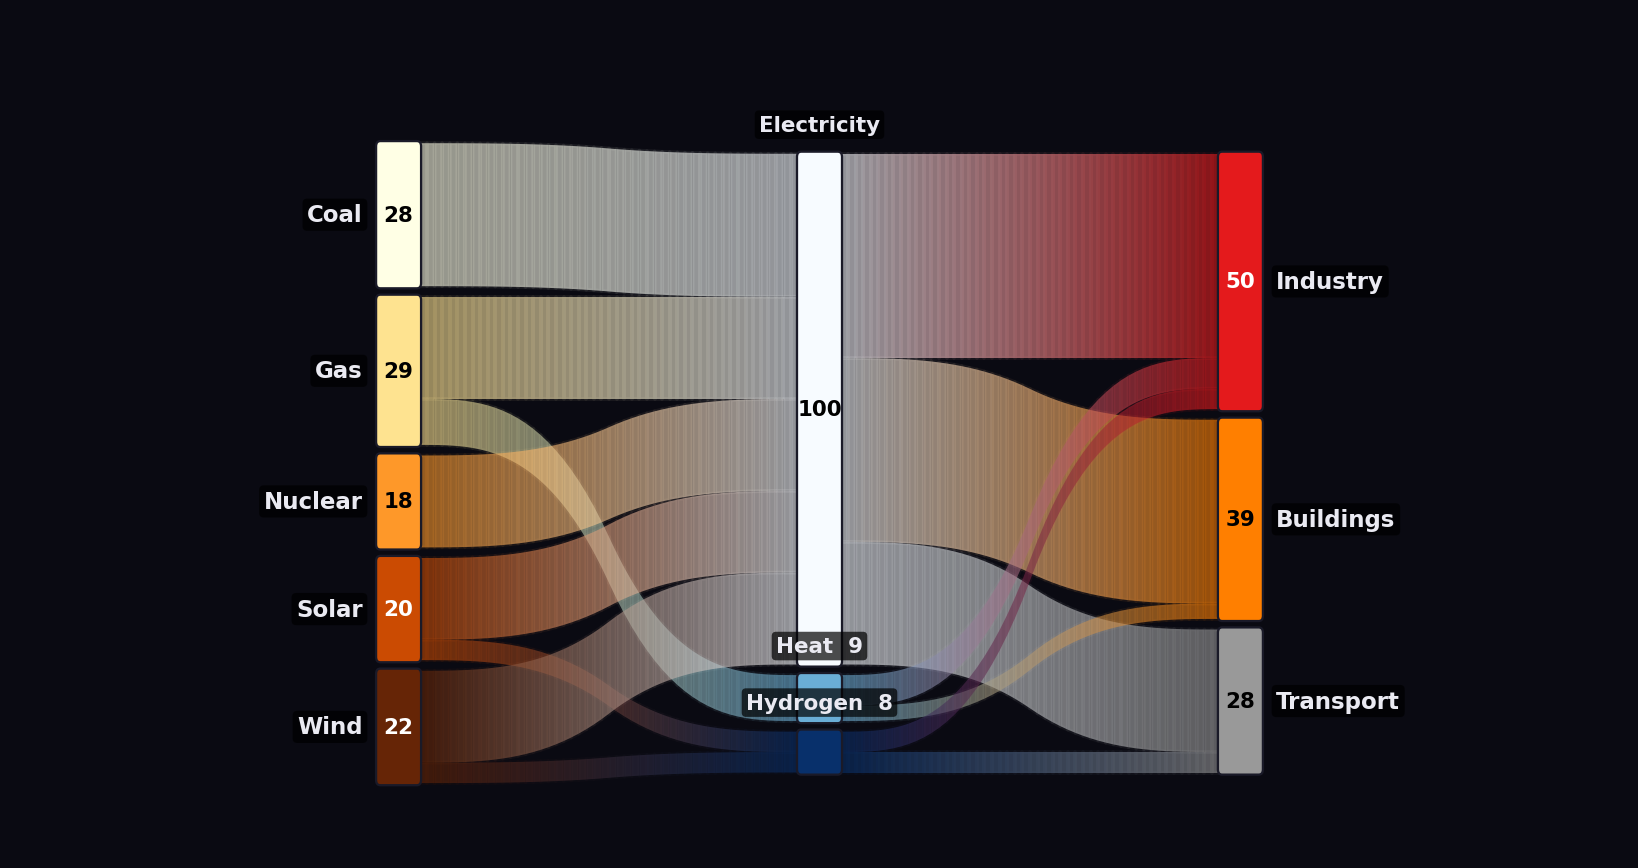

In [4]:
energy_layers = [["Coal", "Gas", "Nuclear", "Solar", "Wind"],
                 ["Electricity", "Heat", "Hydrogen"],
                 ["Industry", "Buildings", "Transport"]]
energy = {
    ("Coal","Electricity"):28, ("Gas","Electricity"):20, ("Gas","Heat"):9,
    ("Nuclear","Electricity"):18, ("Solar","Electricity"):16, ("Solar","Hydrogen"):4,
    ("Wind","Electricity"):18, ("Wind","Hydrogen"):4,
    ("Electricity","Industry"):40, ("Electricity","Buildings"):36, ("Electricity","Transport"):24,
    ("Heat","Industry"):6, ("Heat","Buildings"):3,
    ("Hydrogen","Industry"):4, ("Hydrogen","Transport"):4,
}
pals = [ColorPalette.EARTH, ColorPalette.OCEAN, ColorPalette.NEON]
energy_colors = {}
for nodes, pal in zip(energy_layers, pals):
    for n, c in zip(nodes, get_palette_colors(pal, len(nodes))):
        energy_colors[n] = c

sk = one_period(energy, energy_layers, energy_colors)
sk.save_frame(f"{ASSET}/02_energy.png", figsize=(15, 8), dpi=110, font_size=15,
              theme=Theme.dark(), link_glow=1, link_alpha=0.55,
              stacked_mode=True, ranking_mode=False, padding=2.2)
Image(f"{ASSET}/02_energy.png")

## 3. A multi-layer funnel

Four layers, money/users splitting at every stage — a SaaS acquisition funnel
from visitors to paying customers. Gradients make each path traceable even where
the ribbons cross.

Frame saved to: gallery_assets/03_funnel.png


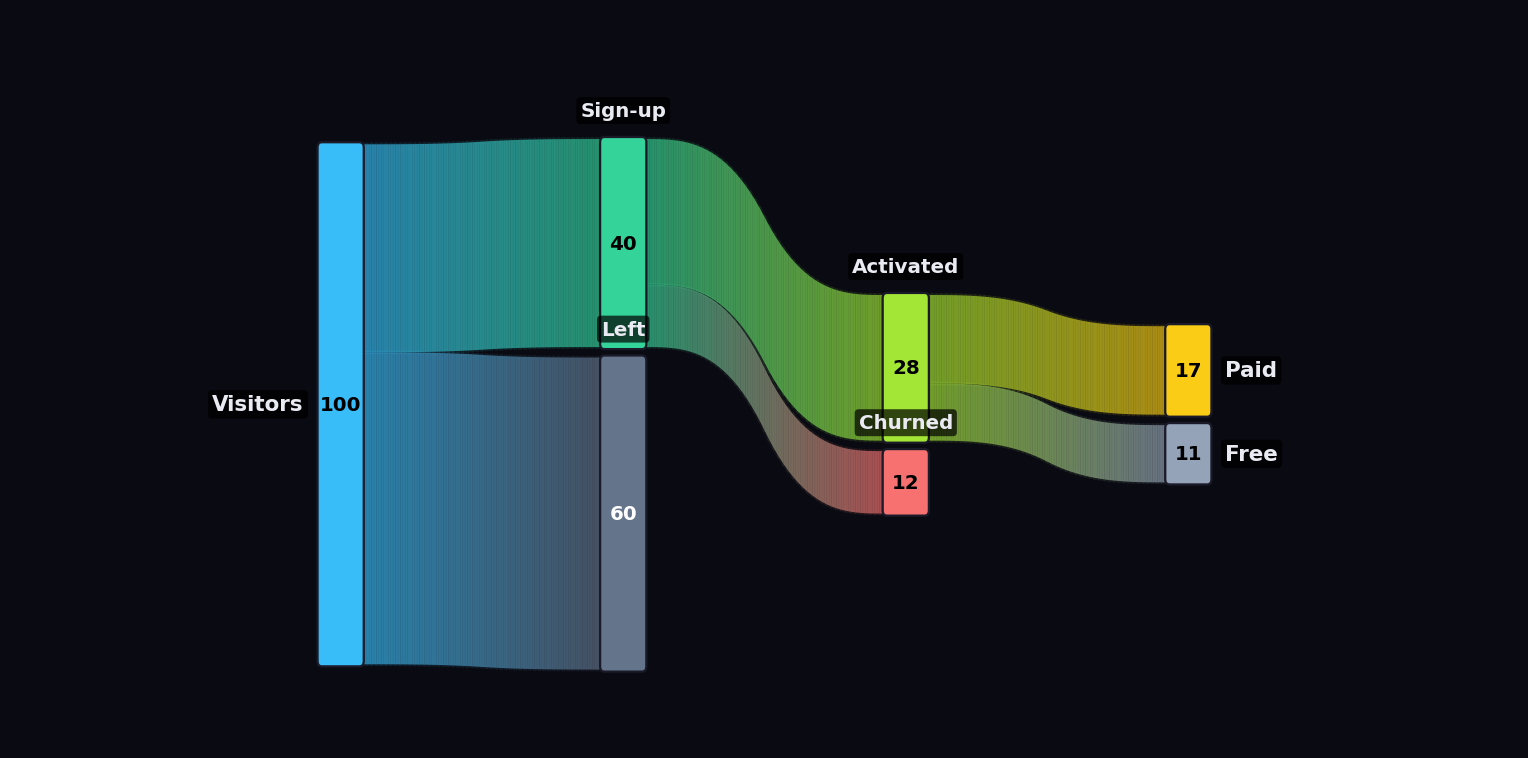

In [5]:
funnel_layers = [["Visitors"], ["Sign-up", "Left"],
                 ["Activated", "Churned"], ["Paid", "Free"]]
funnel = {
    ("Visitors","Sign-up"):40, ("Visitors","Left"):60,
    ("Sign-up","Activated"):28, ("Sign-up","Churned"):12,
    ("Activated","Paid"):17, ("Activated","Free"):11,
}
funnel_colors = {"Visitors":"#38BDF8", "Sign-up":"#34D399", "Left":"#64748B",
                 "Activated":"#A3E635", "Churned":"#F87171", "Paid":"#FACC15", "Free":"#94A3B8"}

sk = one_period(funnel, funnel_layers, funnel_colors)
sk.save_frame(f"{ASSET}/03_funnel.png", figsize=(14, 7), dpi=110, font_size=14,
              theme=Theme.dark(), link_glow=1, link_alpha=0.6,
              stacked_mode=True, ranking_mode=False, padding=1.8)
Image(f"{ASSET}/03_funnel.png")

## 4. One look, three themes

Appearance is controlled by a single cohesive object, `Theme`. The same data,
three shipped presets — **dark**, **light**, **editorial** — no other change.

Frame saved to: gallery_assets/04_theme_dark.png
dark


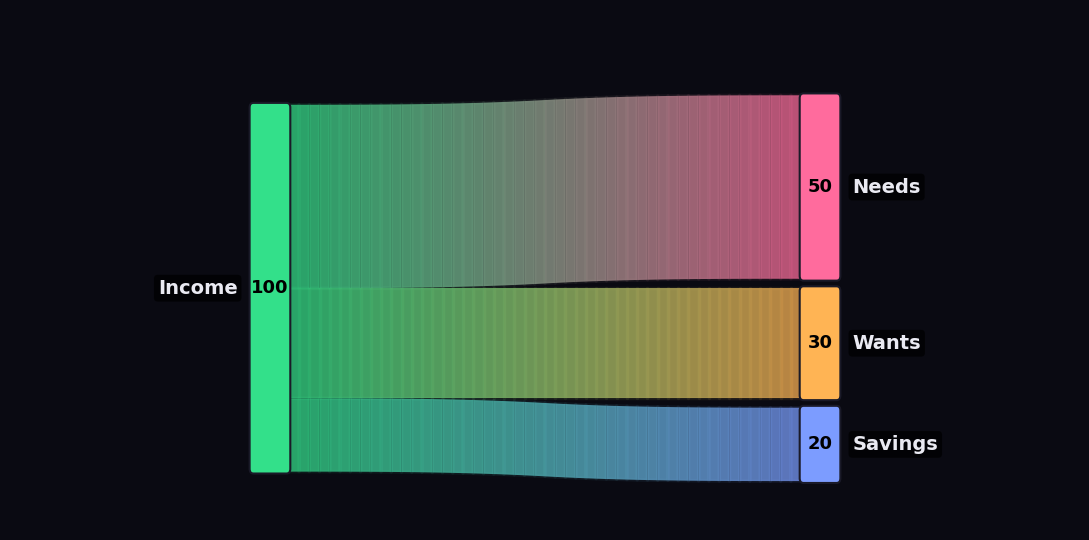

Frame saved to: gallery_assets/04_theme_light.png
light


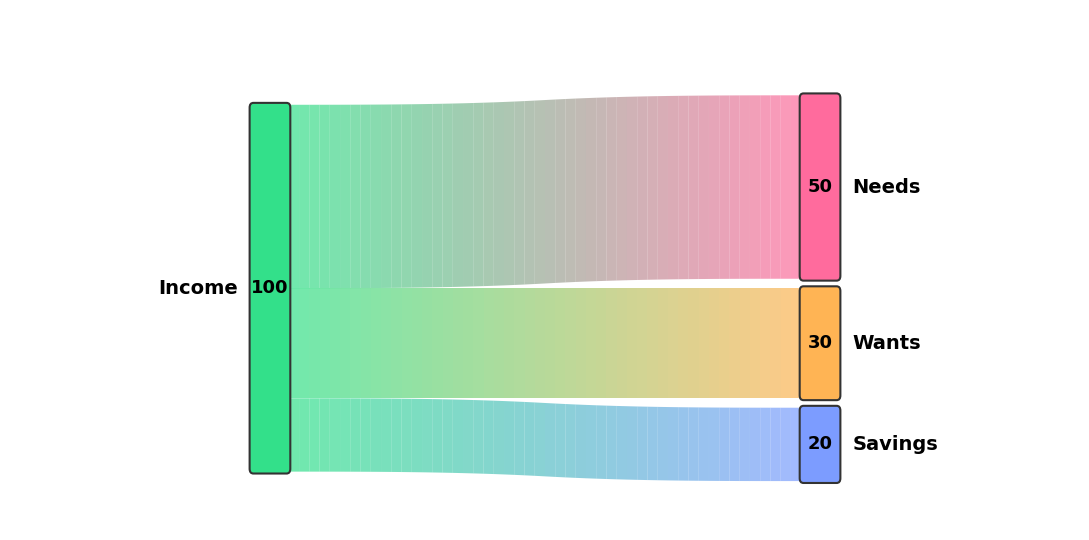

Frame saved to: gallery_assets/04_theme_editorial.png
editorial


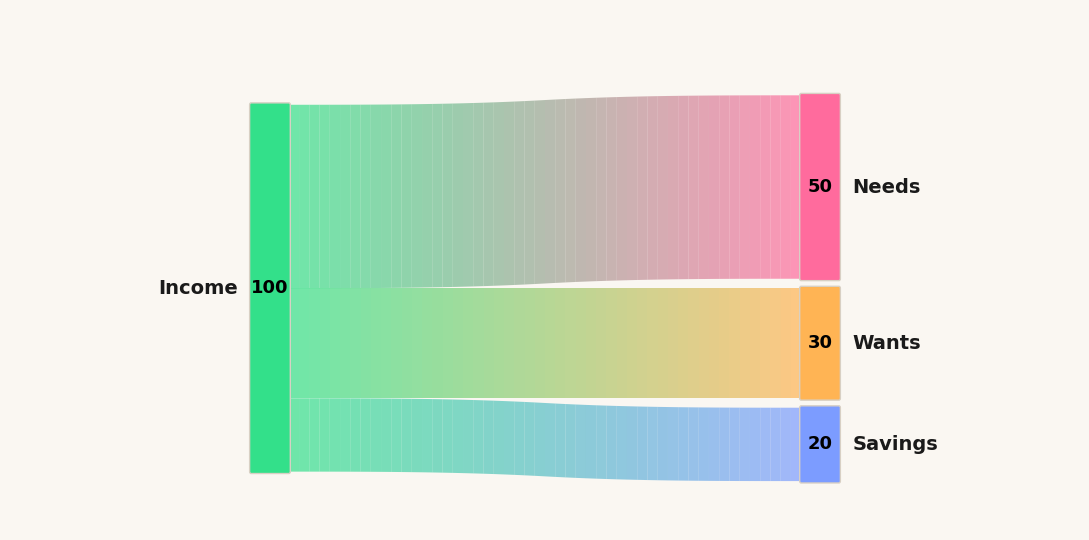

In [6]:
themes = [("dark", Theme.dark()), ("light", Theme.light()), ("editorial", Theme.editorial())]
sk = one_period(budget, budget_layers, budget_colors)
for name, th in themes:
    p = f"{ASSET}/04_theme_{name}.png"
    glow = 1 if name == "dark" else 0
    sk.save_frame(p, figsize=(11, 5.5), dpi=100, font_size=14, theme=th,
                  link_glow=glow, stacked_mode=True, ranking_mode=False, padding=1.6)
    print(name)
    display(Image(p))

## 5. Design control — a custom `Theme`

A `Theme` bundles `node` / `link` / `type` styles you can tune field by field:
pill-shaped nodes, a heavier neon glow, a custom palette — your own signature
look in a few lines.

Frame saved to: gallery_assets/05_custom.png


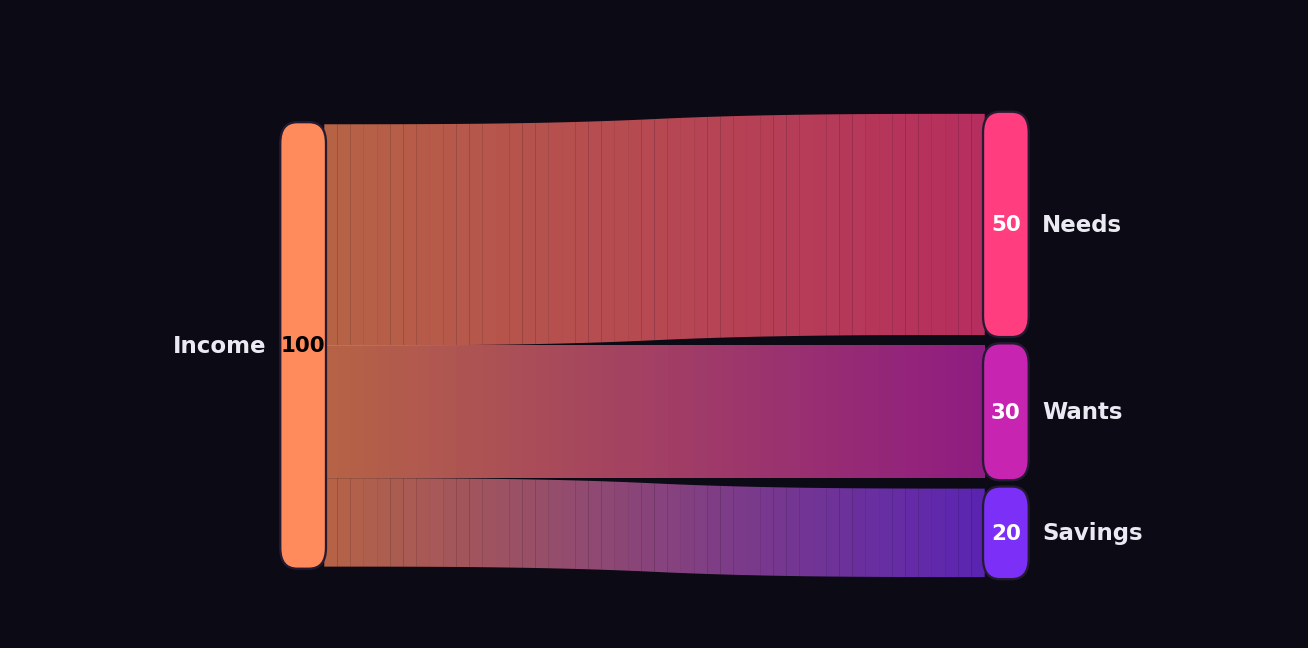

In [7]:
look = Theme.dark()
look.background = "#0c0a14"
look.node.corner_radius = 0.20        # pill-shaped nodes
look.node.edge_color = "#241b33"
look.node.label_plate_alpha = 0.0     # no backing plate — clean over a dark bg
look.link.glow = 3                    # lush neon halo
look.link.alpha = 0.8

sunset = {"Income":"#FF8A5B", "Needs":"#FF3D7F", "Wants":"#C724B1", "Savings":"#7B2FF7"}
sk = one_period(budget, budget_layers, sunset)
sk.save_frame(f"{ASSET}/05_custom.png", figsize=(12, 6), dpi=110, font_size=15,
              theme=look, stacked_mode=True, ranking_mode=False, padding=1.6)
Image(f"{ASSET}/05_custom.png")

## 6. The finale — an animation

Static frames are only half the story. Give the library a flow that **changes
over time** and it interpolates smoothly between periods and renders an MP4.

Here: a decade of the energy transition (2015 → 2025) — coal fades as solar and
wind surge — with dynamic, value-driven coloring and neon glow.

In [8]:
# Build a multi-period dataset: coal declines, renewables rise.
years = list(range(2015, 2026))
rows = []
for i, y in enumerate(years):
    f = i / (len(years) - 1)          # 0 -> 1 across the decade
    coal   = 40 * (1 - 0.7 * f)
    gas    = 22
    nuclear= 16
    solar  = 4 + 30 * f
    wind   = 5 + 26 * f
    gen = {"Coal": coal, "Gas": gas, "Nuclear": nuclear, "Solar": solar, "Wind": wind}
    total = sum(gen.values())
    for src, v in gen.items():
        rows.append({"year": y, "s": src, "d": "Electricity", "v": v})
    # end use split (proportional-ish)
    for use, share in [("Industry", 0.4), ("Buildings", 0.35), ("Transport", 0.25)]:
        rows.append({"year": y, "s": "Electricity", "d": use, "v": total * share})

df = pd.DataFrame(rows)
anim_layers = [["Coal", "Gas", "Nuclear", "Solar", "Wind"], ["Electricity"],
               ["Industry", "Buildings", "Transport"]]
anim_colors = {"Coal":"#6B7280","Gas":"#9CA3AF","Nuclear":"#A78BFA",
               "Solar":"#FFC93C","Wind":"#34D399","Electricity":"#38BDF8",
               "Industry":"#FF6B9D","Buildings":"#FB923C","Transport":"#7C9CFF"}

sk = Sankey.from_dataframe(df, anim_layers, time_col="year", source_col="s",
                           target_col="d", value_col="v", node_colors=anim_colors)
sk.animate(f"{ASSET}/06_energy_transition.mp4",
           title="The energy transition",
           figsize=(13, 7), fps=24, duration_seconds=7.0,
           theme=Theme.dark(), link_glow=1, link_alpha=0.6,
           stacked_mode=True, ranking_mode=False, absolute_scale=True,
           n_workers=2)
print("rendered ->", f"{ASSET}/06_energy_transition.mp4")

Settings (MULTI-LAYER PARALLEL):
  - Layers: 3
  - Nodes per layer: [5, 1, 3]
  - FPS: 24, Duration: 7.0s
  - Quality: medium
  - Total frames: 168
  - Gradient segments: 50
  - Positioning mode: Stacked
  - Dynamic color mode: Static

Pre-computing 168 frames...
  Pre-computation: 0.00s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 16.96s (9.9 fps)

Concatenating 2 chunks...


  Concatenation: 0.22s

Animation saved to: gallery_assets/06_energy_transition.mp4
Total time: 17.19s (9.8 effective fps)
rendered -> gallery_assets/06_energy_transition.mp4


In [9]:
Video(f"{ASSET}/06_energy_transition.mp4", embed=True, width=780)

---

That's the library: a few lines of pandas in, a beautiful gradient Sankey — or a
full animation — out.

```bash
pip install gradient-sankey
```

⭐ [github.com/FG-SC/gradient-sankey](https://github.com/FG-SC/gradient-sankey)
